IMPORTING LIBRARIES

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from collections import Counter

nltk.download("stopwords")
nltk.download("wordnet")



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

LOADING THE DATASET

In [30]:
# Load the dataset
df = pd.read_csv('spam[1].csv', encoding='latin-1')

# Renaming columns for clarity
df = df.rename(columns={'v1': 'Label', 'v2': 'Text'})
df = df[['Label', 'Text']]

print(df.head())

  Label                                               Text
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


PREPROCESSING

In [31]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    text = re.sub(r"\d+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    words = [lemmatizer.lemmatize(word) for word in text.split() if word not in stop_words]
    return " ".join(words)

df["Cleaned_Text"] = df["Text"].apply(preprocess)
df["Word_Count"] = df["Text"].apply(lambda x: len(x.split()))

print("Preprocessing complete.")

Preprocessing complete.


COMPARING SPAM VS HAM

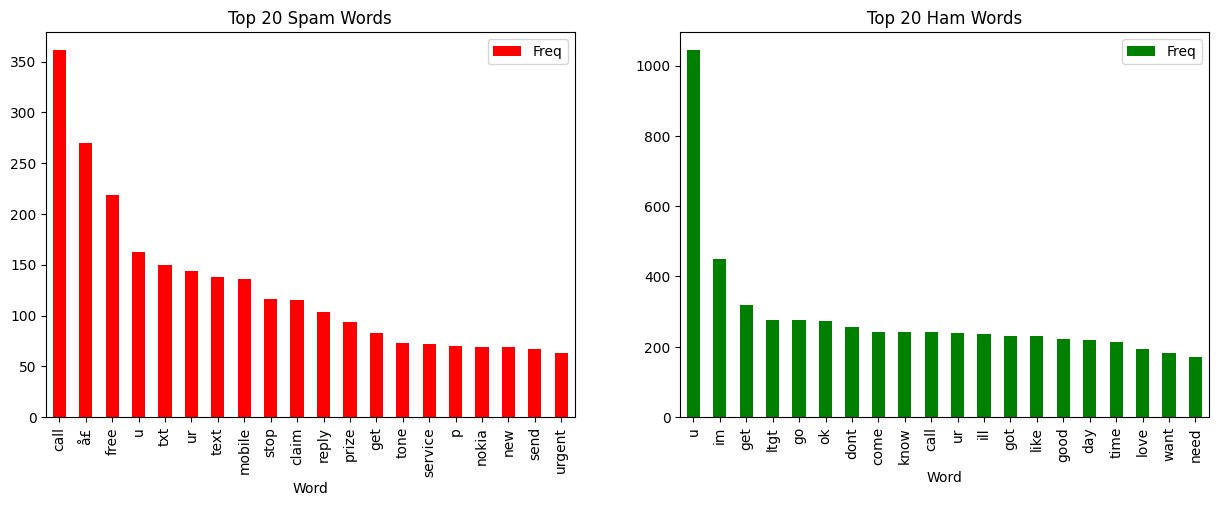

In [32]:
# Analyzing unique vocabulary in Spam vs Ham
spam_words = " ".join(df[df['Label'] == 'spam']['Cleaned_Text']).split()
ham_words = " ".join(df[df['Label'] == 'ham']['Cleaned_Text']).split()

spam_freq = Counter(spam_words).most_common(20)
ham_freq = Counter(ham_words).most_common(20)

# Visualizing top words for both
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
pd.DataFrame(spam_freq, columns=['Word', 'Freq']).plot.bar(x='Word', y='Freq', ax=ax[0], title="Top 20 Spam Words", color='red')
pd.DataFrame(ham_freq, columns=['Word', 'Freq']).plot.bar(x='Word', y='Freq', ax=ax[1], title="Top 20 Ham Words", color='green')
plt.show()

WORD CLOUD

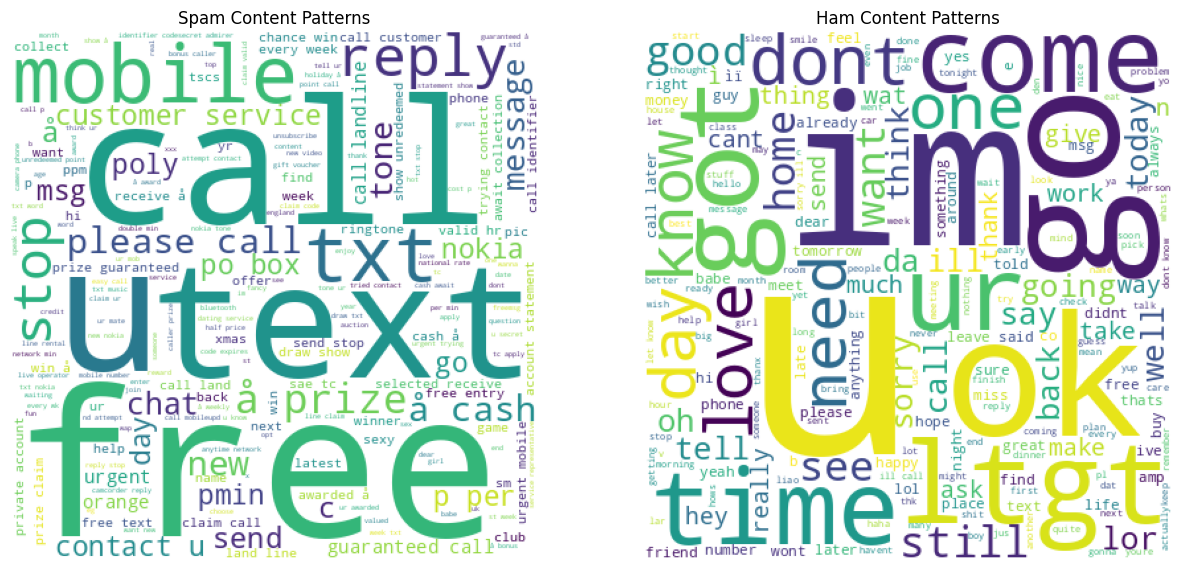

In [33]:
# Generate word clouds to visualize linguistic differences
fig, ax = plt.subplots(1, 2, figsize=(15, 7))

# Spam Cloud
spam_cloud = WordCloud(width=400, height=400, background_color="white").generate(" ".join(spam_words))
ax[0].imshow(spam_cloud)
ax[0].set_title("Spam Content Patterns")
ax[0].axis("off")

# Ham Cloud
ham_cloud = WordCloud(width=400, height=400, background_color="white").generate(" ".join(ham_words))
ax[1].imshow(ham_cloud)
ax[1].set_title("Ham Content Patterns")
ax[1].axis("off")

plt.show()

In [34]:
# Compare average word count per email type
avg_len = df.groupby("Label")["Word_Count"].mean()

print("Average Word Count per Email Category:")
print(avg_len)

# Calculate vocabulary richness (unique words / total words)
def vocab_richness(text_list):
    all_words = " ".join(text_list).split()
    return len(set(all_words)) / len(all_words)

spam_richness = vocab_richness(df[df['Label'] == 'spam']['Cleaned_Text'])
ham_richness = vocab_richness(df[df['Label'] == 'ham']['Cleaned_Text'])

print(f"\nVocabulary Richness (Spam): {spam_richness:.4f}")
print(f"Vocabulary Richness (Ham): {ham_richness:.4f}")

Average Word Count per Email Category:
Label
ham     14.200622
spam    23.851406
Name: Word_Count, dtype: float64

Vocabulary Richness (Spam): 0.1889
Vocabulary Richness (Ham): 0.1741


In [35]:
print("="*60)
print("EMAIL ANALYSIS REPORT")
print("="*60)
print(f"Total Emails Analyzed: {len(df)}")
print(f"Spam Emails: {len(df[df['Label'] == 'spam'])}")
print(f"Ham Emails: {len(df[df['Label'] == 'ham'])}")
print("-" * 60)
print("Key Observations:")
print("1. Spam emails typically rely on high-frequency 'call to action' words.")
print("2. Ham emails show higher vocabulary diversity (richness).")
print("3. Spam emails often have distinct length patterns compared to daily business correspondence.")
print("="*60)

EMAIL ANALYSIS REPORT
Total Emails Analyzed: 5572
Spam Emails: 747
Ham Emails: 4825
------------------------------------------------------------
Key Observations:
1. Spam emails typically rely on high-frequency 'call to action' words.
2. Ham emails show higher vocabulary diversity (richness).
3. Spam emails often have distinct length patterns compared to daily business correspondence.


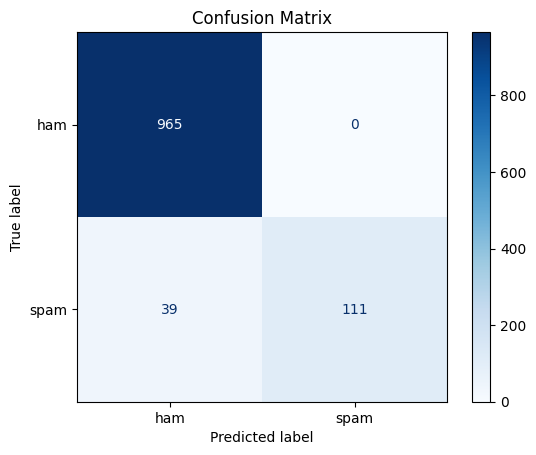

In [36]:
# Confusion matrix
cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

FINAL REPORT

In [37]:
# Calculating stats for the report
total_emails = len(df)
spam_count = len(df[df['Label'] == 'spam'])
ham_count = len(df[df['Label'] == 'ham'])

print("="*60)
print("EMAIL SPAM DETECTION PROJECT REPORT")
print("="*60)
print(f"Total emails analyzed: {total_emails}")
print(f"Number of Spam emails: {spam_count}")
print(f"Number of Ham emails: {ham_count}")
print(f"Model Accuracy: {accuracy_score(y_test, predictions)*100:.2f}%")
print("="*60)

# Final recommendations based on the findings
print("\nRecommendations:")
print("1. Integrate this model into the company email gateway.")
print("2. Periodically retrain the model with new incoming emails to maintain accuracy.")
print("3. Allow users to 'mark as spam' to create a feedback loop for future improvements.")

EMAIL SPAM DETECTION PROJECT REPORT
Total emails analyzed: 5572
Number of Spam emails: 747
Number of Ham emails: 4825
Model Accuracy: 96.50%

Recommendations:
1. Integrate this model into the company email gateway.
2. Periodically retrain the model with new incoming emails to maintain accuracy.
3. Allow users to 'mark as spam' to create a feedback loop for future improvements.
